In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

from clyent import color
from pymatgen.core import Structure
from pymatgen.core.periodic_table import Element

def is_transition_metal(element):
    try:
        return Element(element).is_transition_metal
    except:
        return False

In [2]:
plot_params = {
    "font.family": "Arial",
    "figure.dpi": 300,
    "savefig.format": 'svg',
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.labelweight": "normal"
}

plt.rcParams.update(plot_params)

In [3]:
# struct = Structure.from_file("44-compared.vasp")
struct = Structure.from_file("111.vasp")
# 过渡金属位点
# tm_sites =[]
mn_sites = []
ni_sites = []
co_sites = []
for index, site in enumerate(struct):
    if is_transition_metal(site.specie):
        if site.specie.symbol == "Mn":
            mn_sites.append(index)
        elif site.specie.symbol == "Ni":
            ni_sites.append(index)
        elif site.specie.symbol == "Co":
            co_sites.append(index)

# print(tm_sites)
# print(li_sites)
# print(o_sites)
# li_sites = [0, 1, 2, 3, 4, 5] # 44
# li_sites = [0, 1, 2, 3, 34, 35] # 44-compared


In [4]:
print(ni_sites)

[50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


In [4]:
coords = []
bonds = []
bond_coords = []
bond_energy =[]
bond_energy_up = []
bond_energy_down = []

In [5]:
# data_44 = pd.read_csv("44-compared.csv")
data_44 = pd.read_csv("111.csv")
for row_index in range(len(data_44)):

    atom_1 = int(re.search(r'\d+', data_44.iloc[row_index, :]["atome_1"]).group())
    atom_2 = int(re.search(r'\d+', data_44.iloc[row_index, :]["atome_2"]).group())
    row_bond = (atom_1-1, atom_2-1)

    icohp_up =  - float(data_44.iloc[row_index, :]["icohp-up"])
    icohp_down = - float(data_44.iloc[row_index, :]["icohp-down"])
    icohp_total = icohp_up + icohp_down

    bonds.append(row_bond)
    bond_energy_up.append(icohp_up)
    bond_energy_down.append(icohp_down)
    bond_energy.append(icohp_total)

    coord_1 = struct[atom_1-1].coords
    coord_2 = struct[atom_2-1].coords  # 这里是因为lobster计算时候的索引和pymatgen中的索引开头分别是1和0，为了保持一致减1

    bond_coord = [coord_1, coord_2]
    bond_coords.append(bond_coord)

    coords.append(coord_1)
    coords.append(coord_2) # 需要用到的坐标元组，不重复元素，用于生成坐标轴


coords = np.array(tuple(coords)) # 去掉重复元素并转为np.array

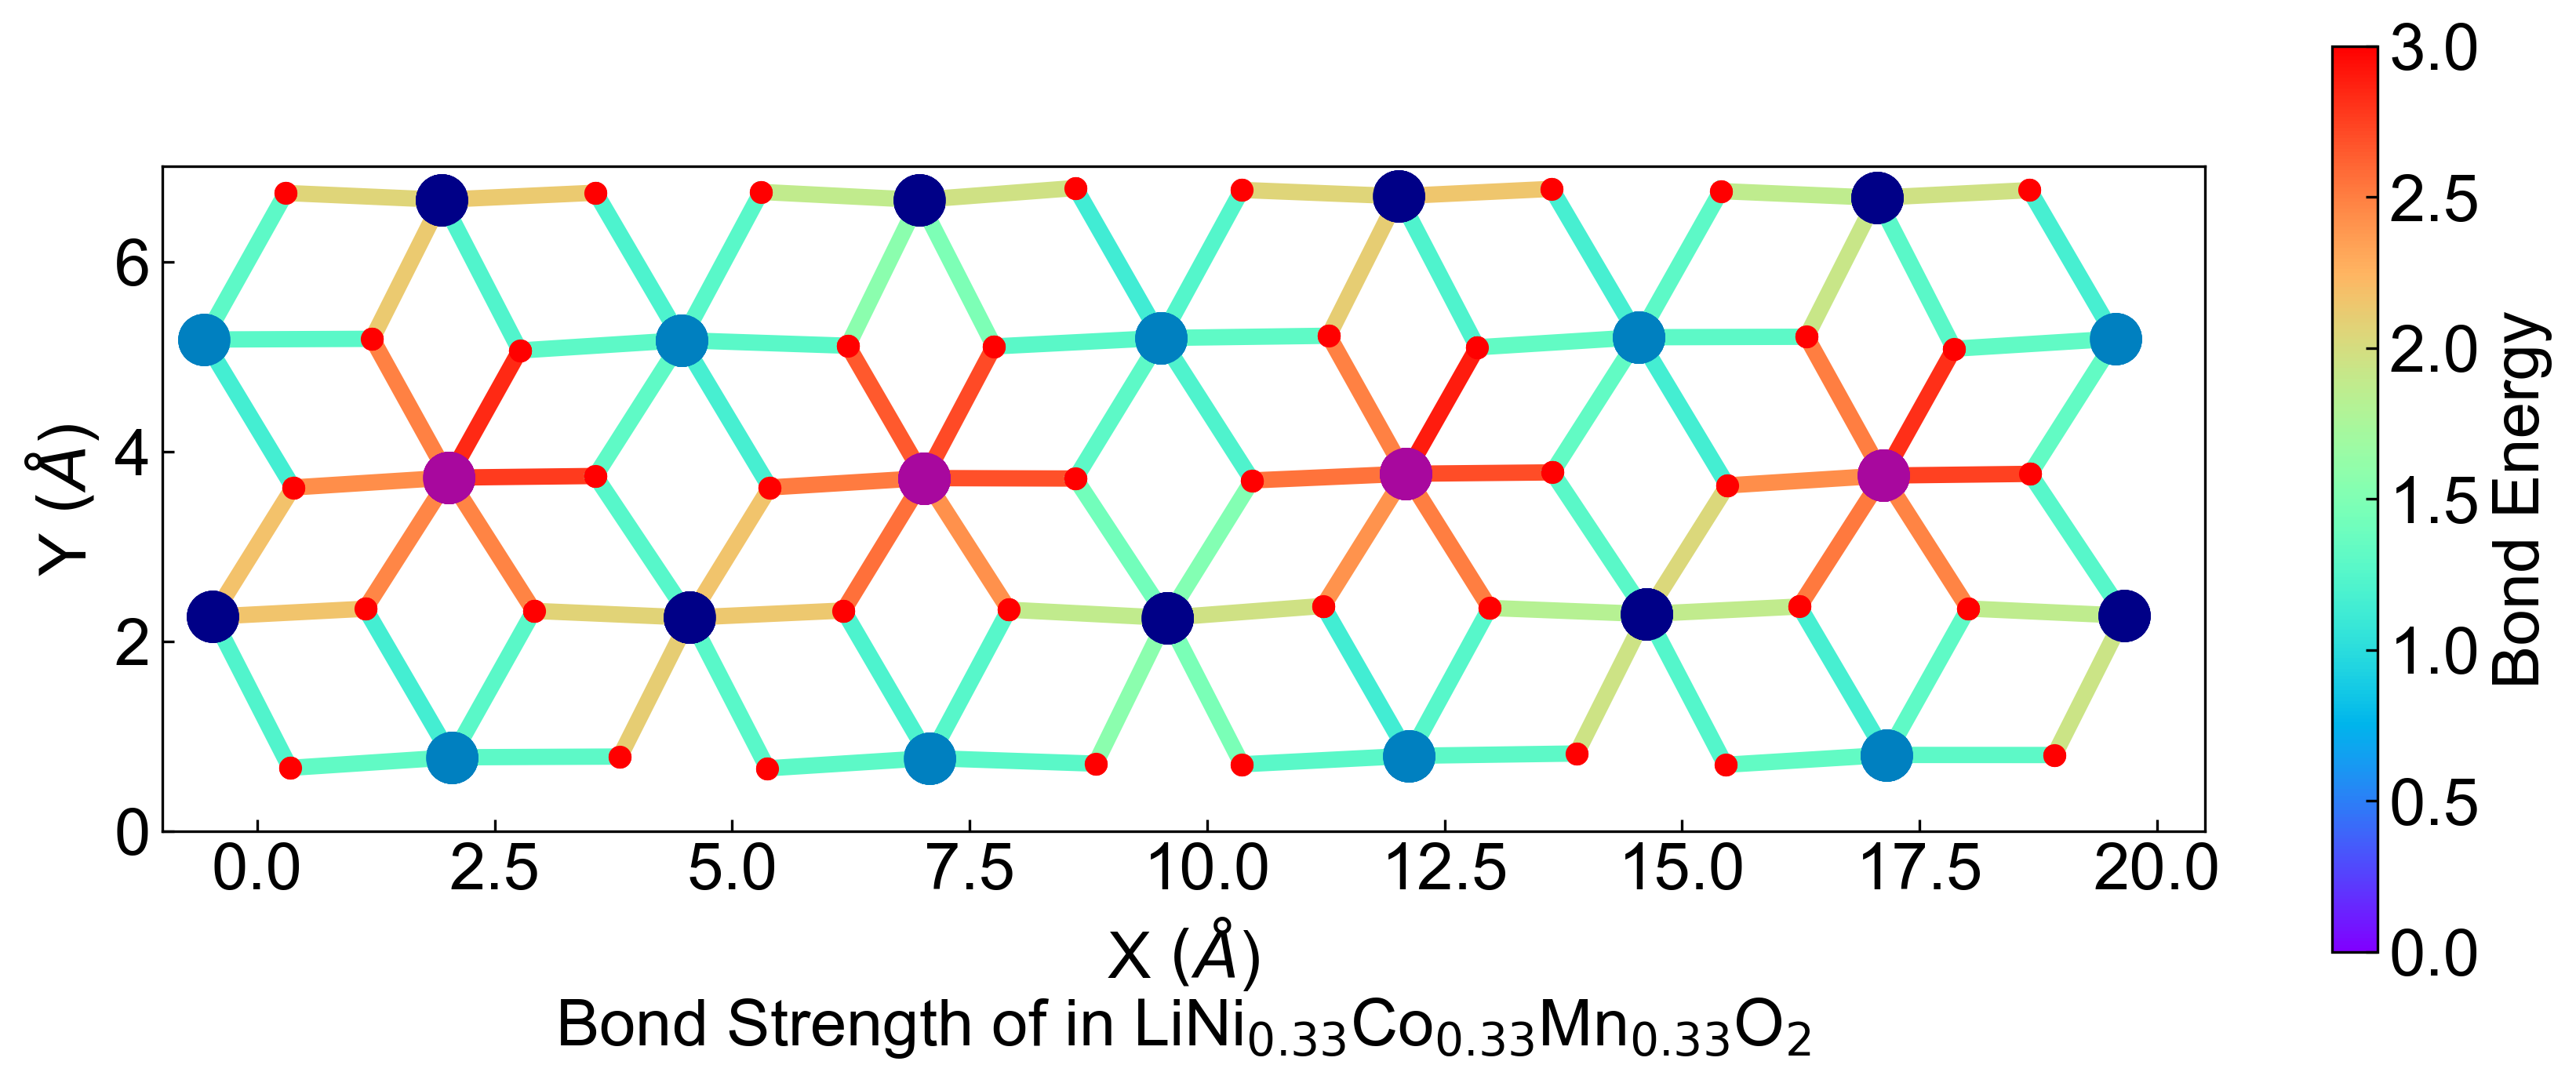

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
# ax.scatter(coords[:, 0], coords[:, 1], c="black", s=40)


# norm = plt.Normalize(vmin=min(bond_energy), vmax=max(bond_energy))  # 这个是颜色映射根据数据来取，可能会导致不同结构的不统一
norm = plt.Normalize(vmin=0, vmax=3)  # 这里自己指定的映射范围
cmap = plt.colormaps["rainbow"]

for (i, j), e in zip(bonds, bond_energy):

    x = [struct[i].coords[0], struct[j].coords[0]]
    y = [struct[i].coords[1], struct[j].coords[1]]
    # print(struct[i], struct[j])
    if 0 < y[0] < 7 and 0 < y[1] < 7  and -1 < x[0] < 20 and -1< x[1] < 20: # 设置展示范围
        ax.plot(x, y, color=cmap(norm(e)), linewidth=5)
        if i in mn_sites:
            ax.plot(x[0], y[0], marker="o", markersize=15, color=(168/255, 8/255, 158/255)) # Mn原子的绘制
            # ax.text(x[0], y[0], "Mn") # 是否标记元素
        elif i in ni_sites: # 全是是2价镍, 标成青色
            ax.plot(x[0], y[0], marker="o", markersize=15, color=(0/255, 128/255, 192/255)) # Ni原子的绘制
            # ax.text(x[0], y[0], "Ni") # 标记元素
        # elif i in ni_sites[3:]: # 其他的是三价镍，标成橙色
        #     ax.plot(x[0], y[0], marker="o", markersize=15, color=(183/255, 187/255, 189/255))
        elif i in co_sites:
            ax.plot(x[0], y[0], marker="o", markersize=15, color=(0/255, 0/255, 135/255))

        ax.plot(x[1], y[1], 'ro')
        # ax.text(x[0], y[0], str(i))
        # ax.text(x[1], y[1], str(j)) # 是否标记点索引



sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Bond Energy", fontsize=20)  # 热图棒设置


# for i in li_sites: # 锂离子位点设置
#     li_coord = struct[i].coords
#     if -1 < li_coord[0] < 22  and 0 < li_coord[1] < 7 :
#         ax.plot(li_coord[0], li_coord[1], 'ro', markersize=20)
ax.set_aspect("equal")
ax.set_ylim([0, 7])
ax.set_xlim([-1, 20.5])
ax.set_xlabel("X $({\AA}$)", fontsize=20)
ax.set_ylabel("Y $({\AA}$)", fontsize=20)
ax.set_title("Bond Strength of in LiNi$_{0.33}$Co$_{0.33}$Mn$_{0.33}$O$_2$",fontsize=20, y=-0.35)
# plt.show()
plt.savefig("111.svg")